### Configure here

In [13]:
# Camelyon16, NSCLC, TCGA_CRC, STANFORD_793
dataset       = "STANFORD_793"
output_folder = "Corrected_paired_t_test"
csv_path      = (f"/data_64T_3/Raja/MUFASA/1.WSI_Classification/Statistical_Analysis/data/{dataset}_Results.csv")
k_folds       = 5
n_repeats     = 1

### Normality test

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
baselines     = ["CLAM", "Histolab", "Trident"]
metrics       = ["macro_auc", "acc", "bacc", "macro_f1"]
metric_labels = ["Macro-AUC", "ACC", "BACC", "Macro-F1"]

# ─────────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────────
df_raw = pd.read_csv(csv_path)
for c in ["acc", "bacc", "macro_auc", "macro_f1"]:
    df_raw[c] = pd.to_numeric(df_raw[c].astype(str).str.strip(), errors="coerce")

print(f"Loaded: {df_raw.shape[0]} rows")
print(f"Methods found: {df_raw['method'].unique().tolist()}")
print(f"Models found:  {df_raw['model'].nunique()} unique models\n")

# ─────────────────────────────────────────────
# BUILD DELTA DATAFRAME
# one row per (model, fold, baseline, metric)
# ─────────────────────────────────────────────
mufasa = df_raw[df_raw['method'] == 'MUFASA'].copy()
rows   = []

for b in baselines:
    base   = df_raw[df_raw['method'] == b].copy()
    merged = mufasa.merge(base,
                          on=['Dataset', 'task', 'model', 'run_id'],
                          suffixes=('_mufasa', '_base'))
    for metric in metrics:
        merged[f'd_{metric}'] = (merged[f'{metric}_mufasa']
                               - merged[f'{metric}_base'])

    for _, row in merged.iterrows():
        for metric in metrics:
            rows.append({
                'model':    row['model'],
                'run_id':   row['run_id'],
                'baseline': b,
                'metric':   metric,
                'delta':    row[f'd_{metric}']
            })

delta_long = pd.DataFrame(rows)
print(f"Delta dataframe: {delta_long.shape[0]} rows")
print(f"  {delta_long['model'].nunique()} models × "
      f"{delta_long['run_id'].nunique()} folds × "
      f"{len(baselines)} baselines × {len(metrics)} metrics\n")

# ─────────────────────────────────────────────
# SHAPIRO-WILK NORMALITY TEST
# ─────────────────────────────────────────────
print("=" * 65)
print("SHAPIRO-WILK NORMALITY TEST ON DELTA DISTRIBUTIONS")
print("H0: deltas are normally distributed")
print("p > 0.05 → normal   |   p <= 0.05 → non-normal")
print("=" * 65)

results = []

for metric, label in zip(metrics, metric_labels):
    print(f"\n{label}:")
    print("-" * 55)
    for baseline in baselines:
        vals = delta_long[
            (delta_long['metric']   == metric) &
            (delta_long['baseline'] == baseline)
        ]['delta'].dropna().values

        if len(vals) >= 3:
            stat, p = shapiro(vals)
            normal  = p > 0.05
            verdict = "normal ✓" if normal else "NON-NORMAL ✗"
            print(f"  MUFASA vs {baseline:10s} | "
                  f"n={len(vals):3d} | "
                  f"W={stat:.4f} | "
                  f"p={p:.4f} | {verdict}")
        else:
            stat, p, normal, verdict = np.nan, np.nan, False, "too few samples"
            print(f"  MUFASA vs {baseline:10s} | n={len(vals)} — {verdict}")

        results.append({
            'metric':   metric,
            'label':    label,
            'baseline': baseline,
            'n':        len(vals),
            'W_stat':   round(stat, 4) if not np.isnan(stat) else np.nan,
            'p_value':  round(p,    4) if not np.isnan(p)    else np.nan,
            'normal':   normal,
            'verdict':  verdict
        })

# ─────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────
results_df = pd.DataFrame(results)

print("\n" + "=" * 65)
print("SUMMARY — recommended test based on normality")
print("=" * 65)

for metric, label in zip(metrics, metric_labels):
    subset      = results_df[results_df['metric'] == metric]
    all_normal  = subset['normal'].all()
    any_normal  = subset['normal'].any()
    recommended = "Paired t-test / N&B" if all_normal else "Wilcoxon / Bootstrap"
    print(f"  {label:12s} → all normal: {str(all_normal):5s} "
          f"→ recommended: {recommended}")

# ─────────────────────────────────────────────
# OVERALL RECOMMENDATION
# ─────────────────────────────────────────────
all_normal_overall = results_df['normal'].all()

print("\n" + "=" * 65)
print("OVERALL RECOMMENDATION")
print("=" * 65)
if all_normal_overall:
    print("""  All deltas are normally distributed.
  → Use Nadeau & Bengio corrected t-test (accounts for CV overlap)
  → Or Linear Mixed Effects Model (accounts for model heterogeneity)""")
else:
    print("""  Some deltas are NON-NORMAL.
  → Use Bootstrap CI (no normality assumption)
  → Or Wilcoxon signed-rank test
  → Mixed Effects Model is still valid (robust to mild non-normality)""")

### Confidence Interval Calculation Corrected resampled t-test (Nadeau & Bengio, 2003)

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import t as t_dist          # ★ replaced ttest_1samp
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 12, 'axes.labelsize': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5,
    'axes.facecolor': 'white', 'axes.edgecolor': 'black',
    'axes.grid': False, 'grid.color': 'lightgray', 'grid.linestyle': '--'
})

# ★ NEW — Nadeau & Bengio corrected resampled t-test
def corrected_resampled_ttest(values, k_folds, n_repeats=1):
    n             = len(values)
    mean          = np.mean(values)
    s2            = np.var(values, ddof=1)
    correction    = (1.0 / n) + (1.0 / (k_folds - 1))
    corrected_var = correction * s2
    if corrected_var <= 0 or np.isnan(corrected_var):
        return np.nan, np.nan, np.nan, np.nan
    se_corr = np.sqrt(corrected_var)
    t_stat  = mean / se_corr
    df      = n - 1
    p_val   = 2 * t_dist.sf(abs(t_stat), df=df)
    t_crit  = t_dist.ppf(0.975, df=df)
    ci_low  = mean - t_crit * se_corr   # ★ correct 95% CI using corrected SE
    ci_high = mean + t_crit * se_corr   #    was: mean ± std  (wrong)
    return float(t_stat), float(p_val), float(ci_low), float(ci_high)

def preprocess_data(csv_path):
    raw = pd.read_csv(csv_path)
    for c in ["acc", "bacc", "macro_auc", "macro_f1"]:
        raw[c] = raw[c].astype(str).str.strip()
        raw[c] = raw[c].str.replace(r"\.\.+", ".", regex=True)
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    bad_mask  = raw[["acc", "bacc", "macro_auc", "macro_f1"]].isna().any(axis=1)
    bad_rows  = raw[bad_mask].copy()
    baselines = ["CLAM", "Histolab", "Trident"]
    mufasa    = raw[raw.method == "MUFASA"].copy()
    deltas    = []
    for b in baselines:
        base   = raw[raw.method == b].copy()
        merged = mufasa.merge(base, on=["Dataset", "task", "model", "run_id"],
                              suffixes=("_mufasa", "_base"))
        merged["d_macro_auc"] = merged["macro_auc_mufasa"] - merged["macro_auc_base"]
        out = merged[["Dataset", "task", "model", "run_id", "d_macro_auc"]].copy()
        out.insert(3, "baseline", b)
        deltas.append(out)
    delta_df = pd.concat(deltas, ignore_index=True).sort_values(
        ["Dataset", "model", "baseline", "run_id"])
    return delta_df, bad_rows

# ★ CHANGED — corrected resampled t-test replaces ttest_1samp
def summarize_results(delta_df, k_folds=5, n_repeats=1):
    summary_rows = []
    for (ds, task, model, baseline), g in delta_df.groupby(
            ["Dataset", "task", "model", "baseline"]):
        values = g["d_macro_auc"].dropna().values
        n      = len(values)

        if n > 1:
            t_stat, p_val, ci_low, ci_high = corrected_resampled_ttest(
                values, k_folds=k_folds, n_repeats=n_repeats)
        else:
            t_stat, p_val, ci_low, ci_high = np.nan, np.nan, np.nan, np.nan

        summary_rows.append({
            "Dataset":    ds,
            "task":       task,
            "model":      model,
            "baseline":   baseline,
            "metric":     "macro_auc",
            "delta_mean": round(float(np.mean(values)), 4),
            "t_stat":     round(float(t_stat), 4) if not np.isnan(t_stat) else np.nan,
            "df":         n - 1,
            "p_value":    round(float(p_val),  4) if not np.isnan(p_val)  else np.nan,
            "n_folds":    n,
            "ci_low":     round(ci_low,  4)        if not np.isnan(ci_low)  else np.nan,
            "ci_high":    round(ci_high, 4)         if not np.isnan(ci_high) else np.nan,
        })
    return pd.DataFrame(summary_rows).sort_values(
        ["Dataset", "model", "metric", "baseline"])

def assess_significance(summary_df):
    return summary_df[
        (summary_df["metric"]  == "macro_auc") &
        (summary_df["p_value"] <  0.05)
    ].copy()

# ─────────────────────────────────────────────
# PLOT — unchanged
# ─────────────────────────────────────────────
def create_compact_forest_plot(summary_df, metric='macro_auc'):
    plot_data = summary_df[summary_df.metric == metric].copy()
    fig, ax   = plt.subplots(figsize=(6, 3))
    baseline_colors = {'CLAM': '#1F77B4', 'Histolab': '#FF7F0E', 'Trident': '#2CA02C'}
    unique_models   = plot_data['model'].unique()
    bar_width       = 0.25
    index           = np.arange(len(unique_models))
    for i, baseline in enumerate(plot_data['baseline'].unique()):
        delta_means, ci_lows, ci_highs = [], [], []
        for model in unique_models:
            row = plot_data[(plot_data['baseline'] == baseline) &
                            (plot_data['model']    == model)]
            if not row.empty:
                delta_means.append(row['delta_mean'].values[0])
                ci_lows.append(row['delta_mean'].values[0] - row['ci_low'].values[0])
                ci_highs.append(row['ci_high'].values[0] - row['delta_mean'].values[0])
            else:
                delta_means.append(0); ci_lows.append(0); ci_highs.append(0)
        ax.bar(index + i * bar_width, delta_means, bar_width,
               yerr=[ci_lows, ci_highs], label=baseline,
               color=baseline_colors[baseline], capsize=3, alpha=0.7,
               error_kw={'elinewidth': 0.75, 'capthick': 0.75, 'ecolor': 'black'})
    ax.set_ylabel('ΔMacro-AUC', fontsize=9)
    ax.set_xticks(index + bar_width)
    ax.set_xticklabels(unique_models, rotation=45, ha='right', fontsize=9)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.legend(title='Baseline', loc='best', title_fontsize=9, fontsize=8.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.grid(True, linestyle=':', which='major', color='grey',
                  alpha=0.7, linewidth=0.7)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(f'{output_folder}/{dataset}_CorrectedTtest_CI.png',  # ★ renamed
                dpi=400, bbox_inches='tight', pad_inches=0.1)
    plt.show()

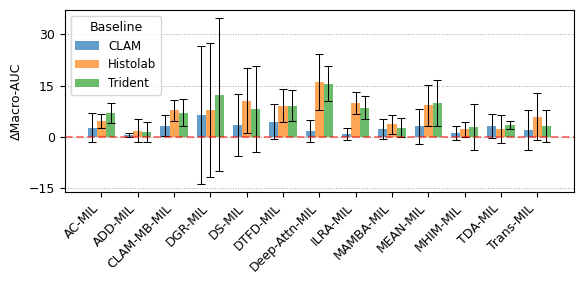


Statistically Significant Improvements (Nadeau & Bengio, p < 0.05):
       Dataset          model  baseline  delta_mean  t_stat  df  p_value  \
1   Camelyon16         AC-MIL  Histolab       4.630  6.2078   4   0.0034   
2   Camelyon16         AC-MIL   Trident       6.904  6.4457   4   0.0030   
3   Camelyon16        ADD-MIL      CLAM       0.562  3.1832   4   0.0334   
6   Camelyon16    CLAM-MB-MIL      CLAM       3.266  2.9765   4   0.0409   
7   Camelyon16    CLAM-MB-MIL  Histolab       7.782  7.1185   4   0.0021   
8   Camelyon16    CLAM-MB-MIL   Trident       7.044  4.9885   4   0.0076   
13  Camelyon16         DS-MIL  Histolab      10.570  3.0875   4   0.0367   
16  Camelyon16       DTFD-MIL  Histolab       9.160  5.2583   4   0.0063   
17  Camelyon16       DTFD-MIL   Trident       9.132  5.5307   4   0.0052   
19  Camelyon16  Deep-Attn-MIL  Histolab      16.044  5.4610   4   0.0055   
20  Camelyon16  Deep-Attn-MIL   Trident      15.566  8.3610   4   0.0011   
22  Camelyon16     

In [5]:
def main():
    os.makedirs(f"{output_folder}/", exist_ok=True)
    delta_df, bad_rows = preprocess_data(csv_path)

    # ★ pass k_folds and n_repeats explicitly
    summary_df       = summarize_results(delta_df, k_folds=k_folds, n_repeats=n_repeats)
    create_compact_forest_plot(summary_df)
    sig_improvements = assess_significance(summary_df)

    print("\nStatistically Significant Improvements (Nadeau & Bengio, p < 0.05):")
    print(sig_improvements[['Dataset', 'model', 'baseline',
                             'delta_mean', 't_stat', 'df',
                             'p_value', 'ci_low', 'ci_high',
                             'n_folds']])          # ★ was 'n' — correct name is 'n_folds'

    summary_df.to_csv(
        f"{output_folder}/{dataset}_CorrectedTtest_Full_Summary.csv",
        index=False, encoding='utf-8-sig')
    sig_improvements.to_csv(
        f"{output_folder}/{dataset}_CorrectedTtest_Significant_Only.csv",
        index=False, encoding='utf-8-sig')
    print(f"\nResults saved to {output_folder}/")

if __name__ == "__main__":
    main()

### Corrected t-test per model based

### Mean and standard deviation for tables in the manuscript and 
### Piared corrected sampled t-test across model

Summary results saved to: Corrected_paired_t_test/STANFORD_793_Mean_Std_Results.csv


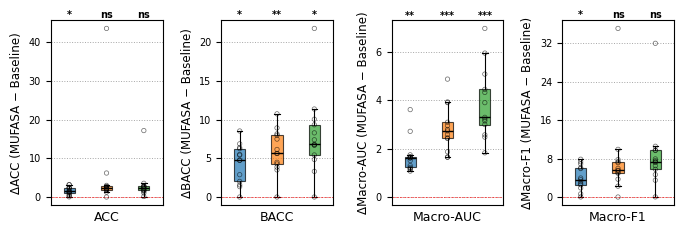

Statistical report saved to: Corrected_paired_t_test/STANFORD_793_CorrectedTtest_Stats_Report.txt
CORRECTED RESAMPLED T-TEST RESULTS (Nadeau & Bengio, 2003)
k_folds=5, n_repeats=1, correction factor 1/(k-1) = 0.2500

ACC (mean_acc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Mean delta:        1.6163
    t-stat (corrected):2.7919
    df:                12
    p-value:           1.6286e-02
    Significance:      * (p < 0.05)
  MUFASA vs. Trident:
    Mean delta:        3.2371
    t-stat (corrected):1.3215
    df:                12
    p-value:           2.1098e-01
    Significance:      ns (p >= 0.05)
  MUFASA vs. Histolab:
    Mean delta:        5.5374
    t-stat (corrected):0.8405
    df:                12
    p-value:           4.1707e-01
    Significance:      ns (p >= 0.05)

BACC (mean_bacc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    Mean delta:        4.3209
    t-stat (corrected):2.9759
    df:    

In [125]:
# ─────────────────────────────────────────────
# CONFIG  (defined before this script runs)
# dataset, output_folder, csv_path, k_folds, n_repeats
# ─────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import t as t_dist          # ★ replaced ttest_1samp
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# NADEAU & BENGIO CORRECTED RESAMPLED T-TEST  ★ added
# ─────────────────────────────────────────────
def corrected_resampled_ttest(values, k_folds, n_repeats=1):
    n      = len(values)
    mean   = np.mean(values)
    s2     = np.var(values, ddof=1)
 
    correction    = (1.0 / n) + (1.0 / (k_folds-1))
    corrected_var = correction * s2

    if corrected_var <= 0 or np.isnan(corrected_var):
        return np.nan, np.nan

    t_stat = mean / np.sqrt(corrected_var)
    df     = n - 1
    p_val  = 2 * t_dist.sf(abs(t_stat), df=df)
    return float(t_stat), float(p_val)

# ─────────────────────────────────────────────
# LOAD & PREPROCESS  (unchanged)
# ─────────────────────────────────────────────
df_raw = pd.read_csv(csv_path)

output_path_csv = f"{output_folder}/{dataset}_Mean_Std_Results.csv"
stats_file_path = f"{output_folder}/{dataset}_CorrectedTtest_Stats_Report.txt"

df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

# grouped = df_raw.groupby(['model', 'method']).agg({
#     'acc':       ['mean', 'std'],
#     'bacc':      ['mean', 'std'],
#     'macro_auc': ['mean', 'std'],
#     'macro_f1':  ['mean', 'std']
# }).reset_index()

# grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns.values]
# grouped.rename(columns={'model': 'Model', 'method': 'Pre-processor'}, inplace=True)

# for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
#     grouped[f'{m}_mean_std'] = grouped.apply(
#         lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

# df = grouped.rename(columns={
#     'acc_mean':       'mean_acc',
#     'bacc_mean':      'mean_bacc',
#     'macro_auc_mean': 'mean_macro-auc',
#     'macro_f1_mean':  'mean_macro-f1'
# })

# Calculate population mean and population std (ddof=0)
grouped = df_raw.groupby(['model', 'method']).agg({
    'acc': ['mean', lambda x: x.std(ddof=0)],
    'bacc': ['mean', lambda x: x.std(ddof=0)],
    'macro_auc': ['mean', lambda x: x.std(ddof=0)],
    'macro_f1': ['mean', lambda x: x.std(ddof=0)]
}).reset_index()

grouped.columns = ['Model', 'Pre-processor', 
                   'acc_mean', 'acc_std', 
                   'bacc_mean', 'bacc_std', 
                   'macro_auc_mean', 'macro_auc_std', 
                   'macro_f1_mean', 'macro_f1_std'] 

# Note: Ensure these strings match the names assigned above exactly
for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
    grouped[f'{m}_mean_std'] = grouped.apply(lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

# Rename columns for the plotting logic (keep these for your deltas/stats)
df = grouped.rename(columns={
    'acc_mean': 'mean_acc',
    'bacc_mean': 'mean_bacc',
    'macro_auc_mean': 'mean_macro-auc',
    'macro_f1_mean': 'mean_macro-f1'
})

os.makedirs(os.path.dirname(output_path_csv), exist_ok=True)
cols_to_save = ['Model', 'Pre-processor', 'acc_mean_std', 'bacc_mean_std',
                'macro_auc_mean_std', 'macro_f1_mean_std']
df[cols_to_save].to_csv(output_path_csv, index=False, encoding='utf-8-sig')
print(f"Summary results saved to: {output_path_csv}")

# ─────────────────────────────────────────────
# PLOT + CORRECTED T-TEST
# ─────────────────────────────────────────────
metrics       = ["mean_acc", "mean_bacc", "mean_macro-auc", "mean_macro-f1"]
metric_labels = ["ACC", "BACC", "Macro-AUC", "Macro-F1"]

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

all_results = {}

order_keys   = ["MUFASA_vs_CLAM", "MUFASA_vs_Histolab", "MUFASA_vs_Trident"]
order_labels = ["CLAM", "Histolab", "Trident"]

baseline_colors = {
    'CLAM':     '#1F77B4',
    'Histolab': '#FF7F0E',
    'Trident':  '#2CA02C'
}
ordered_colors = [baseline_colors[l] for l in order_labels]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]

    pivot_metric = df.pivot(index="Model", columns="Pre-processor", values=metric)

    delta_metric = pd.DataFrame({
        "MUFASA_vs_CLAM":     pivot_metric["MUFASA"] - pivot_metric["CLAM"],
        "MUFASA_vs_Trident":  pivot_metric["MUFASA"] - pivot_metric["Trident"],
        "MUFASA_vs_Histolab": pivot_metric["MUFASA"] - pivot_metric["Histolab"],
    })

    # ── ★ corrected resampled t-test replaces ttest_1samp ────────────────
    results = {}
    for col in delta_metric.columns:
        values = delta_metric[col].dropna().values
        if len(values) > 1:
            t_stat, p = corrected_resampled_ttest(
                values, k_folds=k_folds, n_repeats=n_repeats)
        else:
            t_stat, p = np.nan, np.nan
        results[col] = {
            "mean_delta": float(np.mean(values)),
            "t_stat":     t_stat,
            "p_value":    p,
            "n":          len(values),
            "df":         len(values) - 1
        }
    # ─────────────────────────────────────────────────────────────────────

    all_results[metric] = results

    data_to_plot = [delta_metric[key] for key in order_keys]

    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )

    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, vals in enumerate(data_to_plot, start=1):
        ax.scatter(np.full(len(vals), i), vals,
                   alpha=0.6, s=10, facecolors='none',
                   edgecolors='black', linewidth=0.5, zorder=3)

    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.grid(True, linestyle=':', alpha=0.7, color='grey', linewidth=0.7)
    ax.set_axisbelow(True)

    y_max   = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])

    for i, key in enumerate(order_keys, start=1):
        p_val = results[key]["p_value"]
        if not np.isnan(p_val):
            sig_marker = ("***" if p_val < 0.001 else
                          "**"  if p_val < 0.01  else
                          "*"   if p_val < 0.05  else "ns")
            ax.text(i, y_max + 0.05 * y_range, sig_marker,
                    ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='black')

plt.tight_layout()
os.makedirs(f"{output_folder}/", exist_ok=True)
plt.savefig(f"{output_folder}/{dataset}_CorrectedTtest.png",   # ★ renamed
            dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()

# ─────────────────────────────────────────────
# STATS REPORT  ★ updated caption and labels
# ─────────────────────────────────────────────
caption = f"""
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across metrics.
Corrected resampled t-tests (Nadeau & Bengio, 2003) were performed on mean differences
(ΔMUFASA − Baseline) across all MIL models (n = number of model architectures, k={k_folds} folds,
r={n_repeats} repeat(s)). The correction factor 1/(k-1) accounts for overlap between CV folds.
Each box shows the distribution of performance differences; individual model results are shown
as scatter points. The red dashed line indicates zero difference. Positive values indicate
MUFASA outperforms the baseline.
Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, ns: p >= 0.05.
"""

os.makedirs(os.path.dirname(stats_file_path), exist_ok=True)
with open(stats_file_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("CORRECTED RESAMPLED T-TEST RESULTS (Nadeau & Bengio, 2003)\n")   # ★
    f.write(f"k_folds={k_folds}, n_repeats={n_repeats}, "                     # ★
            f"correction factor 1/(k-1) = {1/(k_folds-1):.4f}\n")
    f.write("=" * 80 + "\n")

    for metric, label in zip(metrics, metric_labels):
        f.write(f"\n{label.upper()} ({metric}):\n")
        f.write("-" * 60 + "\n")
        for comparison, stats in all_results[metric].items():
            baseline = comparison.split("_vs_")[1]
            f.write(f"  MUFASA vs. {baseline}:\n")
            f.write(f"    Mean delta:        {stats['mean_delta']:.4f}\n")
            f.write(f"    t-stat (corrected):{stats['t_stat']:.4f}\n")         # ★
            f.write(f"    df:                {stats['df']}\n")
            p_str = f"{stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "N/A"
            f.write(f"    p-value:           {p_str}\n")
            if not np.isnan(stats['p_value']):
                p   = stats['p_value']
                sig = ("*** (p < 0.001)" if p < 0.001 else
                       "** (p < 0.01)"   if p < 0.01  else
                       "* (p < 0.05)"    if p < 0.05  else
                       "ns (p >= 0.05)")
                f.write(f"    Significance:      {sig}\n")

    f.write("\n" + "=" * 80 + "\n")
    f.write("SUGGESTED FIGURE CAPTION:\n")
    f.write("=" * 80 + "\n")
    f.write(caption + "\n")

print(f"Statistical report saved to: {stats_file_path}")

with open(stats_file_path, "r", encoding="utf-8") as final_report:
    print(final_report.read())

#### Corrected sampled paired t-test fold-wise

Summary results saved to: Corrected_paired_t_test/STANFORD_793_Mean_Std_Results.csv


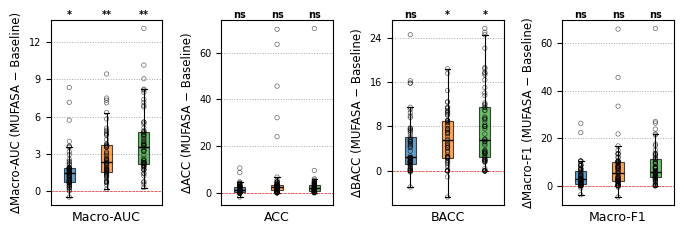

Statistical report saved to: Corrected_paired_t_test/STANFORD_793_Ttest_Stats_Report.txt
CORRECTED RESAMPLED T-TEST RESULTS (Nadeau & Bengio, 2003)
Analysis on: raw per-fold deltas  |  k=5, r=1
correction factor 1/(k-1) = 0.2500

MACRO-AUC (macro_auc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    n (folds × models):  65
    Mean delta:          1.7006
    t-stat (corrected):  2.1840
    df:                  64
    p-value:             3.2637e-02
    Significance:        * (p < 0.05)
  MUFASA vs. Histolab:
    n (folds × models):  65
    Mean delta:          2.8448
    t-stat (corrected):  2.9570
    df:                  64
    p-value:             4.3474e-03
    Significance:        ** (p < 0.01)
  MUFASA vs. Trident:
    n (folds × models):  65
    Mean delta:          3.8709
    t-stat (corrected):  3.0764
    df:                  64
    p-value:             3.0812e-03
    Significance:        ** (p < 0.01)

ACC (acc):
--------------------------

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import t as t_dist          # Nadeau & Bengio
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG  (defined before this block)
# dataset, output_folder, csv_path, k_folds, n_repeats
# ─────────────────────────────────────────────

df_raw = pd.read_csv(csv_path)

output_path_csv = f"{output_folder}/{dataset}_Mean_Std_Results.csv"
stats_file_path = f"{output_folder}/{dataset}_Ttest_Stats_Report.txt"

df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

# ── mean±std table (for CSV summary — unchanged) ─────
grouped = df_raw.groupby(['model', 'method']).agg({
    'acc':       ['mean', 'std'],
    'bacc':      ['mean', 'std'],
    'macro_auc': ['mean', 'std'],
    'macro_f1':  ['mean', 'std']
}).reset_index()

grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns.values]
grouped.rename(columns={'model': 'Model', 'method': 'Pre-processor'}, inplace=True)

for m in ['acc', 'bacc', 'macro_auc', 'macro_f1']:
    grouped[f'{m}_mean_std'] = grouped.apply(
        lambda r: f"{r[m+'_mean']:.2f}±{r[m+'_std']:.2f}", axis=1)

os.makedirs(os.path.dirname(output_path_csv), exist_ok=True)
cols_to_save = ['Model', 'Pre-processor', 'acc_mean_std', 'bacc_mean_std',
                'macro_auc_mean_std', 'macro_f1_mean_std']
grouped[cols_to_save].to_csv(output_path_csv, index=False, encoding='utf-8-sig')
print(f"Summary results saved to: {output_path_csv}")

# ─────────────────────────────────────────────
# NADEAU & BENGIO CORRECTED T-TEST
# ─────────────────────────────────────────────
def corrected_resampled_ttest(values, k_folds, n_repeats=1):
    n             = len(values)
    mean          = np.mean(values)
    s2            = np.var(values, ddof=1)
    correction    = (1.0 / n) + (1.0 / (k_folds - 1))
    corrected_var = correction * s2
    if corrected_var <= 0 or np.isnan(corrected_var):
        return np.nan, np.nan
    t_stat = mean / np.sqrt(corrected_var)
    df     = n - 1
    p_val  = 2 * t_dist.sf(abs(t_stat), df=df)
    return float(t_stat), float(p_val)

# ─────────────────────────────────────────────
# ★ KEY CHANGE: pivot on RAW FOLDS, not averages
# one row per (model, run_id) — folds preserved
# ─────────────────────────────────────────────
metrics       = ["macro_auc", "acc", "bacc", "macro_f1"]
metric_labels = ["Macro-AUC", "ACC", "BACC", "Macro-F1"]

order_keys   = ["MUFASA_vs_CLAM", "MUFASA_vs_Histolab", "MUFASA_vs_Trident"]
order_labels = ["CLAM", "Histolab", "Trident"]

baseline_colors = {
    'CLAM':     '#1F77B4',
    'Histolab': '#FF7F0E',
    'Trident':  '#2CA02C'
}
ordered_colors = [baseline_colors[l] for l in order_labels]

all_results = {}

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]

    # ★ pivot keeping run_id — one row per (model, fold)
    pivot_raw = df_raw.pivot_table(
        index=["model", "run_id"],
        columns="method",
        values=metric
    ).reset_index()

    # ★ delta per fold per model (not on averages)
    delta_df = pd.DataFrame({
        "MUFASA_vs_CLAM":     pivot_raw["MUFASA"] - pivot_raw["CLAM"],
        "MUFASA_vs_Histolab": pivot_raw["MUFASA"] - pivot_raw["Histolab"],
        "MUFASA_vs_Trident":  pivot_raw["MUFASA"] - pivot_raw["Trident"],
    })

    # ★ corrected t-test on raw fold deltas
    results = {}
    for col in order_keys:
        values = delta_df[col].dropna().values
        if len(values) > 1:
            t_stat, p = corrected_resampled_ttest(
                values, k_folds=k_folds, n_repeats=n_repeats)
        else:
            t_stat, p = np.nan, np.nan
        results[col] = {
            "mean_delta": float(np.mean(values)),
            "t_stat":     t_stat,
            "p_value":    p,
            "n":          len(values),
            "df":         len(values) - 1
        }

    all_results[metric] = results

    data_to_plot = [delta_df[key].dropna() for key in order_keys]

    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )

    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, vals in enumerate(data_to_plot, start=1):
        ax.scatter(np.full(len(vals), i), vals,
                   alpha=0.6, s=10, facecolors='none',
                   edgecolors='black', linewidth=0.5, zorder=3)

    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.grid(True, linestyle=':', alpha=0.7, color='grey', linewidth=0.7)
    ax.set_axisbelow(True)

    y_max   = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])

    for i, key in enumerate(order_keys, start=1):
        p_val = results[key]["p_value"]
        if not np.isnan(p_val):
            sig_marker = ("***" if p_val < 0.001 else
                          "**"  if p_val < 0.01  else
                          "*"   if p_val < 0.05  else "ns")
            ax.text(i, y_max + 0.05 * y_range, sig_marker,
                    ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='black')

plt.tight_layout()
os.makedirs(output_folder, exist_ok=True)
plt.savefig(f"{output_folder}/{dataset}_CorrectedTtest.png",
            dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()

# ─────────────────────────────────────────────
# STATS REPORT
# ─────────────────────────────────────────────
caption = f"""
Figure X. Paired comparison of MUFASA pre-processor against baseline methods across metrics.
Corrected resampled t-tests (Nadeau & Bengio, 2003) were performed on per-fold differences
(ΔMUFASA − Baseline) across all MIL models and folds (n = n_models × k_folds, k={k_folds},
r={n_repeats}). The correction factor 1/(k-1) accounts for overlap between CV folds.
Each box shows the distribution of per-fold performance differences; individual fold results
are shown as scatter points. The red dashed line indicates zero difference.
Positive values indicate MUFASA outperforms the baseline.
Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, ns: p >= 0.05.
"""

os.makedirs(os.path.dirname(stats_file_path), exist_ok=True)
with open(stats_file_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("CORRECTED RESAMPLED T-TEST RESULTS (Nadeau & Bengio, 2003)\n")
    f.write(f"Analysis on: raw per-fold deltas  |  k={k_folds}, r={n_repeats}\n")
    f.write(f"correction factor 1/(k-1) = {1/(k_folds-1):.4f}\n")
    f.write("=" * 80 + "\n")

    for metric, label in zip(metrics, metric_labels):
        f.write(f"\n{label.upper()} ({metric}):\n")
        f.write("-" * 60 + "\n")
        for comparison, stats in all_results[metric].items():
            baseline = comparison.split("_vs_")[1]
            f.write(f"  MUFASA vs. {baseline}:\n")
            f.write(f"    n (folds × models):  {stats['n']}\n")
            f.write(f"    Mean delta:          {stats['mean_delta']:.4f}\n")
            f.write(f"    t-stat (corrected):  {stats['t_stat']:.4f}\n")
            f.write(f"    df:                  {stats['df']}\n")
            p_str = f"{stats['p_value']:.4e}" if not np.isnan(stats['p_value']) else "N/A"
            f.write(f"    p-value:             {p_str}\n")
            if not np.isnan(stats['p_value']):
                p   = stats['p_value']
                sig = ("*** (p < 0.001)" if p < 0.001 else
                       "** (p < 0.01)"   if p < 0.01  else
                       "* (p < 0.05)"    if p < 0.05  else
                       "ns (p >= 0.05)")
                f.write(f"    Significance:        {sig}\n")

    f.write("\n" + "=" * 80 + "\n")
    f.write("SUGGESTED FIGURE CAPTION:\n")
    f.write("=" * 80 + "\n")
    f.write(caption + "\n")

print(f"Statistical report saved to: {stats_file_path}")
with open(stats_file_path, "r", encoding="utf-8") as final_report:
    print(final_report.read())

##### Mixed linear

In [14]:
output_folder = "test"

Delta dataframe: 780 rows (13 models × 5 folds × 3 baselines × 4 metrics)

Running Linear Mixed Effects Models...
  Macro-AUC    vs CLAM       | delta=+nan | t=+nan | p=nan
  Macro-AUC    vs Histolab   | delta=+nan | t=+nan | p=nan
  Macro-AUC    vs Trident    | delta=+nan | t=+nan | p=nan
  ACC          vs CLAM       | delta=+1.6163 | t=+5.756 | p=8.6319e-09
  ACC          vs Histolab   | delta=+5.5374 | t=+1.733 | p=8.3150e-02
  ACC          vs Trident    | delta=+nan | t=+nan | p=nan
  BACC         vs CLAM       | delta=+nan | t=+nan | p=nan
  BACC         vs Histolab   | delta=+nan | t=+nan | p=nan
  BACC         vs Trident    | delta=+nan | t=+nan | p=nan
  Macro-F1     vs CLAM       | delta=+nan | t=+nan | p=nan
  Macro-F1     vs Histolab   | delta=+7.7011 | t=+3.234 | p=1.2202e-03
  Macro-F1     vs Trident    | delta=+nan | t=+nan | p=nan

Summary saved to: test/STANFORD_793_MixedEffects_Results.csv


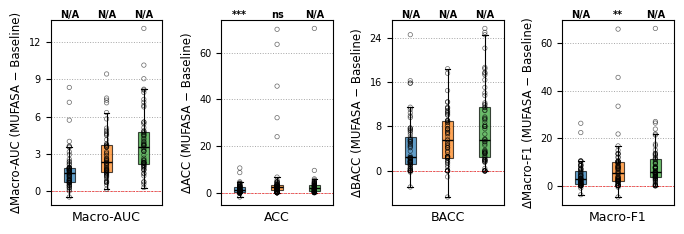

Stats report saved to: test/STANFORD_793_MixedEffects_Stats_Report.txt
LINEAR MIXED EFFECTS MODEL RESULTS
Model: delta ~ 1 + (1 | model_architecture)
Multiple comparison correction: FDR Benjamini-Hochberg

MACRO-AUC (macro_auc):
------------------------------------------------------------
  MUFASA vs. CLAM:
    n observations:   65
    n models:         N/A
    Mean delta:       nan
    t-stat:           nan
    p-value (raw):    N/A
    p-value (FDR):    N/A
    Significance:     N/A
    Converged:        False
  MUFASA vs. Histolab:
    n observations:   65
    n models:         N/A
    Mean delta:       nan
    t-stat:           nan
    p-value (raw):    N/A
    p-value (FDR):    N/A
    Significance:     N/A
    Converged:        False
  MUFASA vs. Trident:
    n observations:   65
    n models:         N/A
    Mean delta:       nan
    t-stat:           nan
    p-value (raw):    N/A
    p-value (FDR):    N/A
    Significance:     N/A
    Converged:        False

ACC (acc):
-------

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
# dataset, output_folder, csv_path defined before this block

df_raw = pd.read_csv(csv_path)

output_path_csv = f"{output_folder}/{dataset}_MixedEffects_Results.csv"
stats_file_path = f"{output_folder}/{dataset}_MixedEffects_Stats_Report.txt"

df_raw['macro_f1'] = pd.to_numeric(df_raw['macro_f1'], errors='coerce')

baselines = ["CLAM", "Histolab", "Trident"]
metrics       = ["macro_auc", "acc", "bacc", "macro_f1"]
metric_labels = ["Macro-AUC", "ACC", "BACC", "Macro-F1"]

baseline_colors = {
    'CLAM':     '#1F77B4',
    'Histolab': '#FF7F0E',
    'Trident':  '#2CA02C'
}

# ─────────────────────────────────────────────
# STEP 1 — BUILD DELTA DATAFRAME
# one row per (model, fold, baseline)
# ─────────────────────────────────────────────
def build_delta_df(df_raw, baselines, metrics):
    """
    For each baseline, compute per-fold delta = MUFASA - baseline.
    Returns long-format dataframe with columns:
      model, run_id, baseline, metric, delta
    """
    mufasa = df_raw[df_raw['method'] == 'MUFASA'].copy()
    rows   = []
    for b in baselines:
        base   = df_raw[df_raw['method'] == b].copy()
        merged = mufasa.merge(base,
                              on=['Dataset', 'task', 'model', 'run_id'],
                              suffixes=('_mufasa', '_base'))
        for metric in metrics:
            merged[f'd_{metric}'] = (merged[f'{metric}_mufasa']
                                   - merged[f'{metric}_base'])

        for _, row in merged.iterrows():
            for metric in metrics:
                rows.append({
                    'model':    row['model'],
                    'run_id':   row['run_id'],
                    'baseline': b,
                    'metric':   metric,
                    'delta':    row[f'd_{metric}']
                })
    return pd.DataFrame(rows)

delta_long = build_delta_df(df_raw, baselines, metrics)
print(f"Delta dataframe: {delta_long.shape[0]} rows "
      f"({delta_long['model'].nunique()} models × "
      f"{delta_long['run_id'].nunique()} folds × "
      f"{len(baselines)} baselines × {len(metrics)} metrics)")

# ─────────────────────────────────────────────
# STEP 2 — LINEAR MIXED EFFECTS MODEL
# fixed effect : intercept (is mean delta != 0?)
# random effect: model architecture
# ─────────────────────────────────────────────
def run_mixed_effects(delta_long, metric, baseline):
    """
    Tests H0: mean delta = 0
    Model architecture treated as random effect —
    accounts for the fact that each model has a
    different baseline performance level.

    delta ~ 1 + (1 | model)
    """
    subset = delta_long[
        (delta_long['metric']   == metric) &
        (delta_long['baseline'] == baseline)
    ][['model', 'delta']].dropna()

    if len(subset) < 3:
        return dict(mean_delta=np.nan, t_stat=np.nan,
                    p_value=np.nan, n=len(subset), converged=False)

    try:
        lme    = smf.mixedlm("delta ~ 1", data=subset,
                              groups=subset["model"])
        result = lme.fit(reml=True, method='lbfgs')

        mean_delta = result.fe_params['Intercept']
        t_stat     = result.tvalues['Intercept']
        p_val      = result.pvalues['Intercept']

        return dict(
            mean_delta = float(mean_delta),
            t_stat     = float(t_stat),
            p_value    = float(p_val),
            n          = int(len(subset)),
            n_models   = int(subset['model'].nunique()),
            converged  = result.converged
        )
    except Exception as e:
        print(f"  Warning: LME failed for {metric} vs {baseline}: {e}")
        return dict(mean_delta=np.nan, t_stat=np.nan,
                    p_value=np.nan, n=len(subset), converged=False)

# ─────────────────────────────────────────────
# STEP 3 — RUN FOR ALL METRICS × BASELINES
# ─────────────────────────────────────────────
all_results = {}
summary_rows = []

print("\nRunning Linear Mixed Effects Models...")
for metric, label in zip(metrics, metric_labels):
    all_results[metric] = {}
    for baseline in baselines:
        res = run_mixed_effects(delta_long, metric, baseline)
        all_results[metric][baseline] = res

        summary_rows.append({
            'metric':     metric,
            'label':      label,
            'baseline':   baseline,
            'mean_delta': res['mean_delta'],
            't_stat':     res['t_stat'],
            'p_value':    res['p_value'],
            'n':          res.get('n', np.nan),
            'n_models':   res.get('n_models', np.nan),
            'converged':  res.get('converged', False)
        })
        print(f"  {label:12s} vs {baseline:10s} | "
              f"delta={res['mean_delta']:+.4f} | "
              f"t={res['t_stat']:+.3f} | "
              f"p={res['p_value']:.4e}")

summary_df = pd.DataFrame(summary_rows)

# ─────────────────────────────────────────────
# STEP 4 — FDR CORRECTION across all tests
# 12 tests total (4 metrics × 3 baselines)
# ─────────────────────────────────────────────
valid_mask = summary_df['p_value'].notna()
p_vals     = summary_df.loc[valid_mask, 'p_value'].values

_, p_corrected, _, _ = multipletests(p_vals, method='fdr_bh')
summary_df.loc[valid_mask, 'p_fdr'] = p_corrected
summary_df.loc[~valid_mask, 'p_fdr'] = np.nan

def sig_stars(p):
    if np.isnan(p): return "N/A"
    if p < 0.001:   return "***"
    if p < 0.01:    return "**"
    if p < 0.05:    return "*"
    return "ns"

summary_df['sig_raw'] = summary_df['p_value'].apply(sig_stars)
summary_df['sig_fdr'] = summary_df['p_fdr'].apply(sig_stars)

os.makedirs(output_folder, exist_ok=True)
summary_df.to_csv(output_path_csv, index=False, encoding='utf-8-sig')
print(f"\nSummary saved to: {output_path_csv}")

# ─────────────────────────────────────────────
# STEP 5 — PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))

order_keys   = [f"MUFASA_vs_{b}" for b in baselines]
order_labels = baselines
ordered_colors = [baseline_colors[b] for b in baselines]

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]

    # raw fold deltas for boxplot
    data_to_plot = []
    for baseline in baselines:
        vals = delta_long[
            (delta_long['metric']   == metric) &
            (delta_long['baseline'] == baseline)
        ]['delta'].dropna().values
        data_to_plot.append(vals)

    bp = ax.boxplot(
        data_to_plot,
        labels=order_labels,
        showfliers=False,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )

    for patch, color in zip(bp['boxes'], ordered_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, vals in enumerate(data_to_plot, start=1):
        ax.scatter(np.full(len(vals), i), vals,
                   alpha=0.6, s=10, facecolors='none',
                   edgecolors='black', linewidth=0.5, zorder=3)

    ax.axhline(0, linestyle="--", color="red", linewidth=0.5, alpha=0.8)
    ax.set_ylabel(f"Δ{label} (MUFASA − Baseline)", fontsize=8.5)
    ax.set_xlabel(f"{label}", fontsize=9)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis='x', which='both', bottom=False,
                   top=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=7)
    ax.yaxis.grid(True, linestyle=':', alpha=0.7,
                  color='grey', linewidth=0.7)
    ax.set_axisbelow(True)

    y_max   = max([v.max() for v in data_to_plot])
    y_range = y_max - min([v.min() for v in data_to_plot])

    # ★ use FDR-corrected p-value for significance stars
    for i, baseline in enumerate(baselines, start=1):
        row   = summary_df[(summary_df['metric']   == metric) &
                           (summary_df['baseline'] == baseline)]
        p_fdr = row['p_fdr'].values[0] if len(row) else np.nan
        ax.text(i, y_max + 0.05 * y_range,
                sig_stars(p_fdr),
                ha='center', va='bottom', fontsize=7,
                fontweight='bold', color='black')

plt.tight_layout()
plt.savefig(f"{output_folder}/{dataset}_MixedEffects.png",
            dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()

# ─────────────────────────────────────────────
# STEP 6 — STATS REPORT
# ─────────────────────────────────────────────
caption = f"""
Figure X. Paired comparison of MUFASA pre-processor against baseline methods.
Linear mixed-effects models were fitted for each metric-baseline pair with model
architecture as a random effect (delta ~ 1 + (1|model)), accounting for the
heterogeneity across {delta_long['model'].nunique()} MIL architectures
(n = {delta_long['run_id'].nunique()} folds × {delta_long['model'].nunique()} models
= {len(delta_long)//len(metrics)//len(baselines)} observations per test).
P-values were corrected for multiple comparisons using the
Benjamini-Hochberg FDR procedure ({len(summary_df)} tests total).
Significance (FDR-corrected): *** p<0.001, ** p<0.01, * p<0.05, ns: p>=0.05.
"""

os.makedirs(os.path.dirname(stats_file_path), exist_ok=True)
with open(stats_file_path, "w", encoding="utf-8") as f:
    f.write("=" * 80 + "\n")
    f.write("LINEAR MIXED EFFECTS MODEL RESULTS\n")
    f.write("Model: delta ~ 1 + (1 | model_architecture)\n")
    f.write("Multiple comparison correction: FDR Benjamini-Hochberg\n")
    f.write("=" * 80 + "\n")

    for metric, label in zip(metrics, metric_labels):
        f.write(f"\n{label.upper()} ({metric}):\n")
        f.write("-" * 60 + "\n")
        for baseline in baselines:
            res = all_results[metric][baseline]
            row = summary_df[(summary_df['metric']   == metric) &
                             (summary_df['baseline'] == baseline)]
            p_fdr = row['p_fdr'].values[0] if len(row) else np.nan

            f.write(f"  MUFASA vs. {baseline}:\n")
            f.write(f"    n observations:   {res.get('n', 'N/A')}\n")
            f.write(f"    n models:         {res.get('n_models', 'N/A')}\n")
            f.write(f"    Mean delta:       {res['mean_delta']:.4f}\n")
            f.write(f"    t-stat:           {res['t_stat']:.4f}\n")
            p_raw = f"{res['p_value']:.4e}" if not np.isnan(res['p_value']) else "N/A"
            p_fdr_str = f"{p_fdr:.4e}" if not np.isnan(p_fdr) else "N/A"
            f.write(f"    p-value (raw):    {p_raw}\n")
            f.write(f"    p-value (FDR):    {p_fdr_str}\n")
            f.write(f"    Significance:     {sig_stars(p_fdr)}\n")
            f.write(f"    Converged:        {res.get('converged', 'N/A')}\n")

    f.write("\n" + "=" * 80 + "\n")
    f.write("SUGGESTED FIGURE CAPTION:\n")
    f.write("=" * 80 + "\n")
    f.write(caption + "\n")

print(f"Stats report saved to: {stats_file_path}")
with open(stats_file_path, "r", encoding="utf-8") as f:
    print(f.read())